# Perception Through Discrete Degrees: Empirical Analysis of NDE Cognition

A statistical analysis of 6,751 near-death experience reports (2 exact duplicates removed) · **Audited and corrected:** 2026-10-05

---

## Framework

Swedenborg's correspondential framework proposes that reality is structured in **discrete degrees** — celestial (love/will), spiritual (wisdom/truth), natural (effects/sensory) — and that the physical body normally constrains perception to the natural degree. During an NDE, when the body's filtering function is suspended, the experiencer should perceive through whatever degree their spiritual constitution already opens to them. The framework therefore predicts a **gradient** of perceptual depth:

| Degree | Orientation | Expected NDE markers | Prevalence prediction |
|--------|------------|---------------------|----------------------|
| Natural (unfiltered) | Sensory/effectual | Enhanced vividness, vivid memory | Most common |
| Spiritual | Truth/understanding | Timelessness, accelerated thought, reality certainty | Moderate |
| Celestial | Love/direct knowing | "More real than real", telepathic communication | Least common |

### Hypotheses

1. Filter-suspension markers are prevalent, with a gradient from common (natural) to rare (celestial)
2. Markers cluster together as a measurable construct
3. The cluster shows internal structure consistent with discrete degrees (2+ factors)
4. Encounter with the Being of Light correlates with deeper perceptual profiles
5. The perceptual profile is constant across religious backgrounds
6. The score distribution shows a gradient, not binary activation

## Audit corrections (2026-10-05)

The previous version computed its statistics correctly but drew several conclusions the analyses could not support.

| # | Issue | Correction |
|---|---|---|
| 1 | A 2-factor solution was *imposed* (`n_factors=2`) and read as "internal differentiation". No factor-retention criterion was applied. | Eigenvalues, parallel analysis, and tetrachoric correlations (appropriate for binary items) all indicate **one** factor. H3 is not supported. |
| 2 | "Right-skewed gradient — exactly what discrete-degree theory predicts; random noise would be roughly normal". | Seven *independent* binary markers with these prevalences are also right-skewed. Skew is not diagnostic; the excess of 0s and 5–7s reflects the common factor. |
| 3 | Prevalence hierarchy (H1) was never tested against the degree assignments. | Most prevalent marker (58%) and least prevalent (15%) are both "spiritual"; hierarchy not observed. |
| 4 | Being-of-Light effect not adjusted for narrative length, although the notebook itself showed d = 1.17 between detailed and less detailed accounts. | Length explains R² ≈ 0.41 of the score; BoL effect falls from +1.09 to +0.39; only 2 of 7 markers remain elevated. |
| 5 | ANOVA p = 0.92 read as "constant across religions" (absence of evidence). | Effect size, Kruskal–Wallis, equivalence test (TOST) and Holm-corrected marker tests added. Christian vs atheist/agnostic equivalence within ±0.5 points is supported. |
| 6 | "Telepathic … of those with communication" used lists that include `no_communication` as the denominator. | Denominator = experiencers with an actual communication mode. |
| 7 | Report described the method as "principal axis"; `factor_analyzer` default is minres. | Stated correctly. |
| 8 | Closing paragraph: "the NDE data **demonstrates** that such perception exists", linked to Palaeolithic signs. | Restated as speculation. |
| 9 | Construct validity (KMO, inter-item correlations) was not checked against narrative length, which drives every marker. | Partial correlations controlling for length added: the mean inter-marker correlation halves (0.29 → 0.15); the six non-telepathic markers still cohere, but telepathy no longer correlates with them. |

## Part I: Data loading and preparation

In [1]:
import sys, json, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu, wilcoxon
from statsmodels.stats.multitest import multipletests

NDE_ROOT = Path.cwd().parent
sys.path.insert(0, str(NDE_ROOT / "scripts"))
import nde_dataset as nd  # verified loader: schema-checked fields, dedup, narrative word counts

OUTPUT_DIR = NDE_ROOT / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

df = nd.load_frame()          # one row per NDE; exact duplicate narratives removed
N = len(df)
print(f"Loaded {N:,} records (after removing exact duplicate narratives)")
print(df["dataset"].value_counts().to_string())


warnings.filterwarnings("ignore", category=FutureWarning)  # factor_analyzer uses a deprecated sklearn argument
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

Loaded 6,751 records (after removing exact duplicate narratives)
dataset
nderf    5659
iands    1092


In [2]:
PERCEPTION_MARKERS = {
    # Natural degree
    "sensory_vividness": ["more_vivid", "incredibly_more_vivid"],
    "memory_persistence": ["more_vivid_than_normal"],
    # Spiritual degree
    "reality_assessment": ["definitely_real"],
    "time_perception": ["timeless", "everything_at_once"],
    "thought_speed": ["incredibly_fast", "faster_than_normal"],
    # Celestial degree
    "comparative_reality": ["more_real_explicit", "more_real_implied"],
}
DEGREE = {"sensory_vividness": "natural", "memory_persistence": "natural", "reality_assessment": "spiritual",
          "time_perception": "spiritual", "thought_speed": "spiritual", "comparative_reality": "celestial", "telepathic": "celestial"}
for var, values in PERCEPTION_MARKERS.items():
    nd.check_values(var, values)        # raises if a value is not in the schema
    print(f"{var}: {df[var].value_counts().to_dict()}")

sensory_vividness: {'not_mentioned': 4150, 'more_vivid': 1214, 'incredibly_more_vivid': 979, 'same': 395, 'less_vivid': 13}
memory_persistence: {'not_mentioned': 4541, 'more_vivid_than_normal': 1948, 'same_as_normal': 195, 'fading': 55, 'less_vivid': 12}
reality_assessment: {'definitely_real': 3927, 'not_mentioned': 2585, 'uncertain': 148, 'probably_real': 71, 'probably_not_real': 20}
time_perception: {'not_mentioned': 4319, 'everything_at_once': 917, 'timeless': 556, 'normal': 494, 'slowed_down': 342, 'speeded_up': 123}
thought_speed: {'not_mentioned': 4872, 'normal': 867, 'incredibly_fast': 596, 'faster_than_normal': 410, 'slower': 6}
comparative_reality: {'not_mentioned': 5628, 'more_real_explicit': 701, 'more_real_implied': 388, 'comparable': 34}


---
## Part II: Perception marker prevalence (H1)

In [3]:
X = pd.DataFrame({f"dp_{k}": nd.isin(df, k, v).astype(int) for k, v in PERCEPTION_MARKERS.items()})
X["dp_telepathic"] = nd.has(df, "communication_modes", "telepathic").astype(int)
dp_cols = list(X.columns)
df = pd.concat([df, X], axis=1)

rows = []
for var, values in PERCEPTION_MARKERS.items():
    mentioned = int((df[var] != "not_mentioned").sum()); marker = int(df[var].isin(values).sum())
    rows.append({"marker": var, "degree": DEGREE[var], "% mentioned": round(100*mentioned/N, 1), "% marker (all)": round(100*marker/N, 1),
                 "% marker (of mentioned)": round(100*marker/mentioned, 1), "% strongest value": round(100*(df[var] == values[0]).mean(), 1)})
real_comm = df["communication_modes"].apply(lambda ms: bool(set(ms) & {"telepathic", "nonverbal", "normal_speech"}))
tel = int(df["dp_telepathic"].sum())
rows.append({"marker": "telepathic", "degree": "celestial", "% mentioned": round(100*real_comm.mean(), 1), "% marker (all)": round(100*tel/N, 1),
             "% marker (of mentioned)": round(100*tel/real_comm.sum(), 1), "% strongest value": np.nan})
prev = pd.DataFrame(rows).sort_values("% marker (all)", ascending=False)
print(prev.to_string(index=False))
print("\n'% mentioned' for telepathic = experiencers reporting a communication mode (telepathic, nonverbal or speech).")

rank = prev["degree"].map({"natural": 1, "spiritual": 2, "celestial": 3})
rho, p = stats.spearmanr(rank, prev["% marker (all)"])
print(f"\nH1 test — predicted degree order (natural > spiritual > celestial) vs prevalence: Spearman ρ = {rho:.2f}, p = {p:.2f}")

             marker    degree  % mentioned  % marker (all)  % marker (of mentioned)  % strongest value
 reality_assessment spiritual         61.7            58.2                     94.3               58.2
  sensory_vividness   natural         38.5            32.5                     84.3               18.0
 memory_persistence   natural         32.7            28.9                     88.1               28.9
         telepathic celestial         56.2            27.0                     48.0                NaN
    time_perception spiritual         36.0            21.8                     60.6                8.2
comparative_reality celestial         16.6            16.1                     97.0               10.4
      thought_speed spiritual         27.8            14.9                     53.5                8.8

'% mentioned' for telepathic = experiencers reporting a communication mode (telepathic, nonverbal or speech).

H1 test — predicted degree order (natural > spiritual > celestia

**Finding (H1 — not supported).** The predicted ordering is not observed: the most prevalent marker (*reality certainty*, 58%) and the least prevalent (*thought speed*, 15%) are both assigned to the spiritual degree, and the celestial "telepathic" marker (27%) is as common as the natural "memory" marker (29%). Across all seven markers the rank correlation between assigned degree and prevalence has the predicted (negative) sign but is not significant (ρ ≈ −0.47, p ≈ 0.28): the spread *within* the spiritual degree (15–58%) is larger than the differences *between* degrees. When a feature *is* mentioned, positive responses dominate (54–97%), so prevalence is driven mainly by whether the narrative addresses the feature at all.

---
## Part III: Construct validity and factor structure (H2, H3)

In [4]:
df["dp_score"] = df[dp_cols].sum(axis=1)
corr = df[dp_cols].corr()
print("Phi (Pearson) correlations:")
print(corr.round(3).to_string())
pairs = [(a, b) for i, a in enumerate(dp_cols) for b in dp_cols[i+1:]]
ps = [stats.spearmanr(df[a], df[b])[1] for a, b in pairs]
print(f"\nPositive pairs: {sum(corr.loc[a, b] > 0 for a, b in pairs)} of 21; significant after Holm: {int((multipletests(ps, method='holm')[1] < 0.05).sum())} of 21")
p_ = df[dp_cols].mean()
kr20 = len(dp_cols) / (len(dp_cols) - 1) * (1 - (p_ * (1 - p_)).sum() / df["dp_score"].var())
chi_square, p_value = calculate_bartlett_sphericity(df[dp_cols])
kmo_all, kmo_model = calculate_kmo(df[dp_cols])
print(f"KR-20 (internal consistency) = {kr20:.3f};  Bartlett χ² = {chi_square:.1f}, p = {p_value:.2g};  KMO = {kmo_model:.3f}")

Phi (Pearson) correlations:
                        dp_sensory_vividness  dp_memory_persistence  dp_reality_assessment  dp_time_perception  dp_thought_speed  dp_comparative_reality  dp_telepathic
dp_sensory_vividness                   1.000                  0.379                  0.381               0.330             0.423                   0.434          0.153
dp_memory_persistence                  0.379                  1.000                  0.415               0.271             0.260                   0.306          0.110
dp_reality_assessment                  0.381                  0.415                  1.000               0.282             0.278                   0.330          0.202
dp_time_perception                     0.330                  0.271                  0.282               1.000             0.391                   0.311          0.194
dp_thought_speed                       0.423                  0.260                  0.278               0.391             1.000    


Positive pairs: 21 of 21; significant after Holm: 21 of 21
KR-20 (internal consistency) = 0.738;  Bartlett χ² = 8480.5, p = 0;  KMO = 0.817


In [5]:
from scipy import optimize
from scipy.stats import multivariate_normal, norm

def tetrachoric(a, b):
    """Maximum-likelihood tetrachoric correlation for two binary vectors."""
    n00 = np.sum((a == 0) & (b == 0)); n01 = np.sum((a == 0) & (b == 1)); n10 = np.sum((a == 1) & (b == 0)); n11 = np.sum((a == 1) & (b == 1))
    ta, tb = norm.ppf(1 - a.mean()), norm.ppf(1 - b.mean())
    def nll(r):
        p00 = multivariate_normal.cdf([ta, tb], mean=[0, 0], cov=[[1, r], [r, 1]])
        pa0, pb0 = norm.cdf(ta), norm.cdf(tb)
        probs = np.clip([p00, pa0 - p00, pb0 - p00, 1 - pa0 - pb0 + p00], 1e-12, 1)
        return -(n00*np.log(probs[0]) + n01*np.log(probs[1]) + n10*np.log(probs[2]) + n11*np.log(probs[3]))
    return optimize.minimize_scalar(nll, bounds=(-0.99, 0.99), method="bounded").x

T = np.eye(len(dp_cols))
for i in range(len(dp_cols)):
    for j in range(i + 1, len(dp_cols)):
        T[i, j] = T[j, i] = tetrachoric(df[dp_cols[i]].values, df[dp_cols[j]].values)
print("Tetrachoric correlations:")
print(pd.DataFrame(T, index=dp_cols, columns=dp_cols).round(2).to_string())

ev_phi = np.sort(np.linalg.eigvalsh(corr.values))[::-1]
ev_tet = np.sort(np.linalg.eigvalsh(T))[::-1]
rng = np.random.default_rng(1)
sims = [np.sort(np.linalg.eigvalsh(np.corrcoef(np.column_stack([rng.permutation(df[c].values) for c in dp_cols]).T)))[::-1] for _ in range(500)]
pa95 = np.percentile(sims, 95, axis=0)
print("\nEigenvalues (phi):        ", ev_phi.round(3))
print("Parallel analysis 95th %: ", pa95.round(3))
print("Eigenvalues (tetrachoric):", ev_tet.round(3))
print(f"Factors retained — Kaiser (phi): {int((ev_phi > 1).sum())}; parallel analysis: {int((ev_phi > pa95).sum())}; Kaiser (tetrachoric): {int((ev_tet > 1).sum())}")

Tetrachoric correlations:
                        dp_sensory_vividness  dp_memory_persistence  dp_reality_assessment  dp_time_perception  dp_thought_speed  dp_comparative_reality  dp_telepathic
dp_sensory_vividness                    1.00                   0.58                   0.62                0.53              0.71                    0.71           0.26
dp_memory_persistence                   0.58                   1.00                   0.70                0.45              0.46                    0.52           0.19
dp_reality_assessment                   0.62                   0.70                   1.00                0.52              0.59                    0.71           0.35
dp_time_perception                      0.53                   0.45                   0.52                1.00              0.64                    0.53           0.34
dp_thought_speed                        0.71                   0.46                   0.59                0.64              1.00      


Eigenvalues (phi):         [2.798 0.94  0.858 0.705 0.632 0.572 0.495]
Parallel analysis 95th %:  [1.062 1.04  1.023 1.008 0.995 0.983 0.968]
Eigenvalues (tetrachoric): [4.114 0.888 0.684 0.482 0.383 0.303 0.146]
Factors retained — Kaiser (phi): 1; parallel analysis: 1; Kaiser (tetrachoric): 1


In [6]:
fa1 = FactorAnalyzer(n_factors=1, rotation=None, method="minres"); fa1.fit(df[dp_cols])
fa2 = FactorAnalyzer(n_factors=2, rotation="varimax", method="minres"); fa2.fit(df[dp_cols])
load = pd.DataFrame({"1-factor": np.abs(fa1.loadings_[:, 0]), "2f: F1": fa2.loadings_[:, 0], "2f: F2": fa2.loadings_[:, 1]}, index=dp_cols)
load["degree"] = [DEGREE[c.replace("dp_", "")] for c in dp_cols]
load["prevalence"] = df[dp_cols].mean().round(3)
print(load.round(3).to_string())
print(f"\nVariance explained: 1 factor {100*fa1.get_factor_variance()[1][0]:.1f}%; 2 factors {100*fa2.get_factor_variance()[1][0]:.1f}% + {100*fa2.get_factor_variance()[1][1]:.1f}%")
fat = FactorAnalyzer(n_factors=1, rotation=None, method="minres", is_corr_matrix=True); fat.fit(T)
print("1-factor loadings on tetrachoric matrix:", dict(zip([c.replace('dp_', '') for c in dp_cols], np.abs(fat.loadings_[:, 0]).round(2))))

                        1-factor  2f: F1  2f: F2     degree  prevalence
dp_sensory_vividness       0.684   0.469   0.483    natural       0.325
dp_memory_persistence      0.546   0.559   0.220    natural       0.289
dp_reality_assessment      0.583   0.619   0.224  spiritual       0.582
dp_time_perception         0.540   0.266   0.511  spiritual       0.218
dp_thought_speed           0.554   0.202   0.635  spiritual       0.149
dp_comparative_reality     0.587   0.441   0.373  celestial       0.161
dp_telepathic              0.297   0.213   0.201  celestial       0.270

Variance explained: 1 factor 30.5%; 2 factors 18.1% + 16.8%
1-factor loadings on tetrachoric matrix: {'sensory_vividness': np.float64(0.82), 'memory_persistence': np.float64(0.69), 'reality_assessment': np.float64(0.83), 'time_perception': np.float64(0.69), 'thought_speed': np.float64(0.75), 'comparative_reality': np.float64(0.8), 'telepathic': np.float64(0.4)}


### Does the construct survive control for narrative length?

Longer accounts mention more of everything (Part IV), so part of the inter-marker correlation may reflect reporting completeness rather than a shared perceptual state. Below, each marker is residualised on log word count (linear and quadratic), and the correlation structure is re-examined.

In [7]:
Zl = np.column_stack([np.ones(N), df["log_words"], df["log_words"] ** 2])
Xv = df[dp_cols].values.astype(float)
Rl = Xv - Zl @ np.linalg.lstsq(Zl, Xv, rcond=None)[0]
pcorr = pd.DataFrame(np.corrcoef(Rl.T), index=dp_cols, columns=dp_cols)
print("Partial correlations, controlling for narrative length:")
print(pcorr.round(3).to_string())
iu = np.triu_indices(len(dp_cols), 1)
r_part = pcorr.values[iu]
t_part = r_part * np.sqrt((N - 5) / (1 - r_part ** 2))
sig_part = multipletests(2 * stats.t.sf(np.abs(t_part), N - 5), method="holm")[1] < 0.05
print(f"\nMean inter-marker correlation: raw {corr.values[iu].mean():.3f} -> length-controlled {r_part.mean():.3f}")
print(f"Positive: {int((r_part > 0).sum())} of 21; significant after Holm: {int(sig_part.sum())} of 21")
tel_i = dp_cols.index("dp_telepathic")
non_tel = np.array([tel_i not in (i, j) for i, j in zip(*iu)])
print(f"Six non-telepathic markers: mean partial r = {r_part[non_tel].mean():.3f}; {int(sig_part[non_tel].sum())} of {int(non_tel.sum())} significant after Holm")
print("Telepathic with the other markers:", pcorr.loc["dp_telepathic"].drop("dp_telepathic").round(3).to_dict())

ev_part = np.sort(np.linalg.eigvalsh(pcorr.values))[::-1]
rng = np.random.default_rng(2)
sims = [np.sort(np.linalg.eigvalsh(np.corrcoef(np.column_stack([rng.permutation(Rl[:, j]) for j in range(Rl.shape[1])]).T)))[::-1] for _ in range(500)]
pa95_part = np.percentile(sims, 95, axis=0)
print("\nEigenvalues (length-controlled):", ev_part.round(3))
print("Parallel analysis 95th %:       ", pa95_part.round(3))
print(f"Components above the parallel-analysis threshold: {int(np.argmin(ev_part > pa95_part))}")
w_, v_ = np.linalg.eigh(pcorr.values); order = np.argsort(w_)[::-1][:3]
pcl = pd.DataFrame(v_[:, order] * np.sqrt(w_[order]), index=dp_cols, columns=["PC1", "PC2", "PC3"])
pcl = pcl * np.sign(pcl.sum())  # orient each component so its loadings sum positive
print("\nPrincipal-component loadings of the three retained components:")
print(pcl.round(2).to_string())
fa2p = FactorAnalyzer(n_factors=2, rotation="varimax", method="minres", is_corr_matrix=True); fa2p.fit(pcorr.values)
lp = pd.DataFrame(fa2p.loadings_, index=dp_cols, columns=["F1", "F2"]); lp["degree"] = [DEGREE[c.replace("dp_", "")] for c in dp_cols]
print("\n2-factor (minres, varimax) loadings on the length-controlled matrix:")
print(lp.round(2).to_string())

qq = pd.qcut(df["word_count"], 5, labels=False)
def kr20_of(sub):
    pp = sub.mean()
    return len(dp_cols) / (len(dp_cols) - 1) * (1 - (pp * (1 - pp)).sum() / sub.sum(axis=1).var())
print("\nKR-20 within narrative-length quintiles (shortest -> longest):", [float(round(kr20_of(df.loc[qq == k, dp_cols]), 2)) for k in range(5)])

Partial correlations, controlling for narrative length:
                        dp_sensory_vividness  dp_memory_persistence  dp_reality_assessment  dp_time_perception  dp_thought_speed  dp_comparative_reality  dp_telepathic
dp_sensory_vividness                   1.000                  0.250                  0.205               0.168             0.300                   0.324          0.005
dp_memory_persistence                  0.250                  1.000                  0.275               0.119             0.123                   0.188         -0.025
dp_reality_assessment                  0.205                  0.275                  1.000               0.082             0.104                   0.189          0.041
dp_time_perception                     0.168                  0.119                  0.082               1.000             0.260                   0.172          0.053
dp_thought_speed                       0.300                  0.123                  0.104              


Eigenvalues (length-controlled): [1.996 1.066 1.038 0.831 0.761 0.711 0.598]
Parallel analysis 95th %:        [1.061 1.039 1.022 1.007 0.995 0.984 0.969]
Components above the parallel-analysis threshold: 3

Principal-component loadings of the three retained components:
                         PC1   PC2   PC3
dp_sensory_vividness    0.70 -0.04 -0.11
dp_memory_persistence   0.56 -0.49  0.06
dp_reality_assessment   0.52 -0.45  0.30
dp_time_perception      0.48  0.46 -0.28
dp_thought_speed        0.55  0.33 -0.44
dp_comparative_reality  0.61  0.11  0.30
dp_telepathic           0.12  0.53  0.76

2-factor (minres, varimax) loadings on the length-controlled matrix:
                          F1    F2     degree
dp_sensory_vividness    0.44  0.40    natural
dp_memory_persistence   0.13  0.49    natural
dp_reality_assessment   0.08  0.49  spiritual
dp_time_perception      0.40  0.10  spiritual
dp_thought_speed        0.58  0.09  spiritual
dp_comparative_reality  0.30  0.37  celestial
dp_telepa

**Findings.**
- *H2 — supported for six of the seven markers:* all 21 raw inter-marker correlations are positive and significant; KR-20 ≈ 0.74; KMO ≈ 0.82. About half of this shared variance is narrative length: controlling for length, the mean inter-marker correlation falls from 0.29 to 0.15. The six non-telepathic markers remain positively and significantly inter-correlated (15/15 after Holm), so a perceptual construct survives that is not merely "longer accounts mention more". **Telepathic communication does not**: once length is controlled, its correlations with the other markers are near zero (−0.03 to 0.05) except with comparative reality (0.13). Its place in the raw scale comes mainly from narrative length. KR-20 within length quintiles is 0.40–0.65.
- *H3 — not supported:* on the raw data only **one** eigenvalue exceeds 1 (≈2.8, then ≈0.94), parallel analysis retains one factor, and on tetrachoric correlations (the appropriate metric for binary items) the first eigenvalue is ≈4.1 against ≈0.9 for the second. The 2-factor varimax solution reported previously was imposed rather than found. After length control, the second and third eigenvalues (1.07, 1.04) only just exceed the parallel-analysis thresholds (1.06, 1.02): a weak second dimension contrasts time perception, thought speed and telepathy with memory and reality certainty, and the third component is dominated by telepathy (loading 0.76). Neither follows the proposed assignment — reality certainty ("spiritual") groups with memory ("natural"), and the two "celestial" markers do not form a factor. The data describe **one dominant dimension of perceptual intensity** with minor sub-structure that does not correspond to discrete degrees.

---
## Part IV: The score distribution (H6) and the narrative-detail confound

In [8]:
obs = df["dp_score"].value_counts().sort_index().reindex(range(8), fill_value=0) / N
dist = np.array([1.0])
for q in df[dp_cols].mean().values:
    dist = np.convolve(dist, [1 - q, q])
def skew_of(probs):
    k = np.arange(len(probs)); m = (probs * k).sum(); v = (probs * (k - m) ** 2).sum()
    return (probs * (k - m) ** 3).sum() / v ** 1.5
comp = pd.DataFrame({"observed %": (100 * obs).round(1), "independent markers %": (100 * dist).round(1)})
print(comp.T.to_string())
print(f"\nMean {df.dp_score.mean():.2f}; skewness observed {stats.skew(df.dp_score):.2f} vs {skew_of(dist):.2f} if the seven markers were independent")
tiers = pd.cut(df["dp_score"], [-1, 0, 2, 4, 7], labels=["0", "1–2", "3–4", "5–7"])
print("\nDepth tiers (%):", (100 * tiers.value_counts(normalize=True).sort_index()).round(1).to_dict())
print("Depth tiers (n):", tiers.value_counts().sort_index().to_dict())
print("\nMarker prevalence (%) by tier:")
print((100 * df.groupby(tiers, observed=True)[dp_cols].mean()).round(1).T.to_string())

dp_score                  0     1     2     3    4    5    6    7
observed %             27.4  21.9  16.7  12.6  9.5  5.8  3.9  2.3
independent markers %   8.2  27.0  33.7  21.6  7.8  1.6  0.2  0.0

Mean 1.99; skewness observed 0.82 vs 0.33 if the seven markers were independent

Depth tiers (%): {'0': 27.4, '1–2': 38.6, '3–4': 22.1, '5–7': 12.0}
Depth tiers (n): {'0': 1848, '1–2': 2603, '3–4': 1492, '5–7': 808}

Marker prevalence (%) by tier:
dp_score                  0   1–2   3–4   5–7
dp_sensory_vividness    0.0  16.9  65.5  95.9
dp_memory_persistence   0.0  17.9  54.9  81.9
dp_reality_assessment   0.0  65.3  95.4  99.5
dp_time_perception      0.0  10.2  36.4  82.2
dp_thought_speed        0.0   3.6  23.4  69.8
dp_comparative_reality  0.0   2.9  27.2  75.2
dp_telepathic           0.0  26.4  40.2  66.0


In [9]:
import statsmodels.formula.api as smf
rho, p = stats.spearmanr(df["dp_score"], df["word_count"])
r2 = smf.ols("dp_score ~ log_words", data=df).fit().rsquared
print(f"Score vs narrative length: Spearman ρ = {rho:.2f} (p = {p:.2g}); R² from log word count alone = {r2:.2f}")
q = pd.qcut(df["word_count"], 5, labels=["Q1 shortest", "Q2", "Q3", "Q4", "Q5 longest"])
print(df.groupby(q, observed=True).agg(median_words=("word_count", "median"), mean_score=("dp_score", "mean"),
                                       pct_zero=("dp_score", lambda s: round(100*(s == 0).mean(), 1))).round(2).to_string())

Score vs narrative length: Spearman ρ = 0.67 (p = 0); R² from log word count alone = 0.41


             median_words  mean_score  pct_zero
word_count                                     
Q1 shortest         186.5        0.52      64.8
Q2                  376.0        1.10      36.7
Q3                  684.0        1.60      23.7
Q4                 1277.0        2.79       8.5
Q5 longest         2417.0        3.96       3.0


**Findings (H6).** The distribution is right-skewed with many zeros (27%) and a tail of high scores. However:
- A right skew is expected for *any* sum of uncommon binary markers — seven independent markers with these prevalences would also be right-skewed (skew ≈ 0.33). The skew alone is not diagnostic of discrete degrees.
- What distinguishes the observed distribution from independence is the excess of 0s and of 5–7s — the signature of a single common factor (Part III).
- That factor is strongly tied to **how much the narrative says**: log word count alone explains ~41% of the score variance; the shortest fifth of accounts average under 1 marker, the longest fifth about 3½. Part of the "gradient" is therefore a gradient of reporting detail. The data cannot separate "deeper perception" from "fuller description".

The gradient is *consistent with* the discrete-degrees prediction, but it is also what a reporting-completeness model predicts, so it does not discriminate between them.

---
## Part V: Being of Light and perceptual depth (H4)

In [10]:
bol, nob = df.loc[df.bol_encounter, "dp_score"], df.loc[~df.bol_encounter, "dp_score"]
t_stat, t_p = stats.ttest_ind(bol, nob)
u = mannwhitneyu(bol, nob)
pooled = np.sqrt(((len(bol)-1)*bol.var() + (len(nob)-1)*nob.var()) / (len(bol)+len(nob)-2))
print(f"With BoL (n={len(bol)}): mean {bol.mean():.2f}, median {bol.median():.0f}, SD {bol.std():.2f};  without (n={len(nob)}): mean {nob.mean():.2f}, median {nob.median():.0f}, SD {nob.std():.2f}")
print(f"t = {t_stat:.2f}, p = {t_p:.2g};  Mann-Whitney U = {u.statistic:,.0f}, p = {u.pvalue:.2g};  Cohen's d = {(bol.mean()-nob.mean())/pooled:.3f}")
m0 = smf.ols("dp_score ~ bol", data=df.assign(bol=df.bol_encounter.astype(int))).fit()
m1 = smf.ols("dp_score ~ bol + log_words", data=df.assign(bol=df.bol_encounter.astype(int))).fit()
ci = m1.conf_int().loc["bol"]
print(f"BoL difference crude {m0.params['bol']:+.2f}; adjusted for log word count {m1.params['bol']:+.2f} (95% CI {ci[0]:.2f} to {ci[1]:.2f}), p = {m1.pvalues['bol']:.2g}")
print(f"Median words: BoL {df.loc[df.bol_encounter,'word_count'].median():.0f} vs {df.loc[~df.bol_encounter,'word_count'].median():.0f}")

With BoL (n=797): mean 2.95, median 3, SD 2.03;  without (n=5954): mean 1.86, median 1, SD 1.82
t = 15.61, p = 5.5e-54;  Mann-Whitney U = 3,122,058, p = 1.6e-49;  Cohen's d = 0.589
BoL difference crude +1.09; adjusted for log word count +0.39 (95% CI 0.28 to 0.49), p = 3e-12
Median words: BoL 1238 vs 626


In [11]:
rows = []
for c in dp_cols:
    t = pd.crosstab(df.bol_encounter, df[c]); chi2, p, _, _ = chi2_contingency(t)
    a = nd.adjusted_odds_ratio(df.assign(y=df[c], b=df.bol_encounter.astype(int)), "y", "b")
    rows.append({"marker": c.replace("dp_", ""), "degree": DEGREE[c.replace("dp_", "")], "with BoL %": round(100*df.loc[df.bol_encounter, c].mean(), 1),
                 "without %": round(100*df.loc[~df.bol_encounter, c].mean(), 1), "χ²": round(chi2, 1), "p": p,
                 "crude OR": round(a["crude_or"], 2), "length-adj OR": round(a["adj_or"], 2), "adj 95% CI": f"{a['adj_ci'][0]:.2f}–{a['adj_ci'][1]:.2f}", "adj p": a["adj_p"]})
bol_tab = pd.DataFrame(rows)
print(bol_tab.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
comm = df["communication_modes"].apply(lambda ms: bool(set(ms) & {"telepathic", "nonverbal", "normal_speech"}))
print(f"\nAny communication: BoL {100*comm[df.bol_encounter].mean():.1f}% vs {100*comm[~df.bol_encounter].mean():.1f}%")
print(f"Telepathic AMONG those who communicated: BoL {100*df.loc[df.bol_encounter & comm, 'dp_telepathic'].mean():.1f}% vs {100*df.loc[~df.bol_encounter & comm, 'dp_telepathic'].mean():.1f}%")

             marker    degree  with BoL %  without %    χ²          p  crude OR  length-adj OR adj 95% CI     adj p
  sensory_vividness   natural        44.3       30.9  56.8  4.747e-14      1.78           1.02  0.86–1.21     0.807
 memory_persistence   natural          34       28.2  11.4  0.0007418      1.31           0.74  0.62–0.88 0.0007498
 reality_assessment spiritual        71.9       56.3  69.3  8.342e-17      1.98           1.07  0.88–1.29    0.4987
    time_perception spiritual        31.7       20.5  51.5   7.06e-13       1.8           0.95  0.79–1.14    0.5805
      thought_speed spiritual        20.8       14.1  24.5  7.416e-07       1.6           0.78  0.63–0.96   0.01919
comparative_reality celestial        32.6       13.9 180.3  4.199e-41      2.99           1.87  1.56–2.25  1.66e-11
         telepathic celestial        59.8       22.6   494 1.965e-109      5.11            3.9  3.31–4.59 6.695e-60

Any communication: BoL 88.8% vs 51.8%
Telepathic AMONG those who commun

**Findings (H4 — partially supported).**
- Crude: Being-of-Light accounts score about one marker higher (d ≈ 0.59) and every marker is elevated.
- After adjusting for narrative length the difference shrinks to about 0.4 markers. Only **comparative reality** ("more real than real") and **telepathic communication** remain clearly elevated; sensory vividness, reality certainty and time perception are no longer different, and memory persistence and thought speed are *lower* in Being-of-Light accounts once length is controlled.
- Part of the telepathy effect is structural: communication of any kind is far more common when a being is present (≈89% vs ≈52%). Among those who communicated, telepathy is still more common in BoL encounters (≈67% vs ≈44%).
- The two markers that survive are the ones assigned to the celestial degree; this is a genuine, framework-consistent pattern, but it rests on two markers, one of which is partly definitional.

---
## Part VI: Constant state across religious backgrounds (H5)

**Limitation:** religious background is not mentioned in ~76% of records; the identified-religion subgroup consists of much longer accounts and is 85% Christian.

In [12]:
main = ["christian", "atheist_agnostic", "spiritual_not_religious", "jewish", "buddhist", "hindu", "muslim"]
rel = df[df["religious_background"].isin(main)]
dist_rel = df["religious_background"].value_counts().to_frame("n")
dist_rel["% of all"] = (100 * dist_rel["n"] / N).round(1)
print("Religious background, full sample:")
print(dist_rel.to_string())
print(f"\nSeven named backgrounds: n = {len(rel)} ({100*len(rel)/N:.1f}% of all); Christian share {100*(rel.religious_background == 'christian').mean():.1f}%\n")
g = rel.groupby("religious_background")["dp_score"].agg(["count", "mean", "std", "median"]).sort_values("count", ascending=False)
print(g.round(2).to_string())
f_stat, f_p = stats.f_oneway(*[x.values for _, x in rel.groupby("religious_background")["dp_score"]])
grand = rel["dp_score"].mean()
eta2 = sum(len(x) * (x.mean() - grand) ** 2 for _, x in rel.groupby("religious_background")["dp_score"]) / ((rel["dp_score"] - grand) ** 2).sum()
kw = stats.kruskal(*[x.values for _, x in rel.groupby("religious_background")["dp_score"]])
print(f"\nANOVA F = {f_stat:.3f}, p = {f_p:.3f}, η² = {eta2:.4f};  Kruskal–Wallis H = {kw.statistic:.2f}, p = {kw.pvalue:.3f}")

from statsmodels.stats.weightstats import ttost_ind
c, a = rel.loc[rel.religious_background == "christian", "dp_score"], rel.loc[rel.religious_background == "atheist_agnostic", "dp_score"]
d = c.mean() - a.mean(); se = np.sqrt(c.var()/len(c) + a.var()/len(a))
tost_p = ttost_ind(c, a, -0.5, 0.5, usevar="unequal")[0]
print(f"Christian − atheist/agnostic = {d:+.3f} markers (95% CI {d-1.96*se:+.2f} to {d+1.96*se:+.2f}); TOST equivalence within ±0.5: p = {tost_p:.3f}")
ca = rel[rel.religious_background.isin(["christian", "atheist_agnostic"])].assign(christian=lambda d_: (d_.religious_background == "christian").astype(int))
ma = smf.ols("dp_score ~ christian + log_words", data=ca).fit(); cia = ma.conf_int().loc["christian"]
print(f"Length-adjusted Christian − atheist/agnostic = {ma.params['christian']:+.3f} (95% CI {cia[0]:+.2f} to {cia[1]:+.2f}); "
      f"median words {ca.loc[ca.christian == 1, 'word_count'].median():.0f} vs {ca.loc[ca.christian == 0, 'word_count'].median():.0f}")

rows = []
for col in dp_cols:
    t = pd.crosstab(rel["religious_background"], rel[col])
    chi2, p, dof, expected = chi2_contingency(t)
    rows.append({"marker": col.replace("dp_", ""), "χ²": round(chi2, 1), "df": dof, "p": round(p, 4), "cells exp<5 %": round(100*(expected < 5).mean())})
mk = pd.DataFrame(rows); mk["p_holm"] = multipletests(mk["p"], method="holm")[1].round(3)
print(mk.to_string(index=False))

ident = df["religious_background"].isin(main)
d_id = (df.loc[ident, "dp_score"].mean() - df.loc[~ident & (df.religious_background == "not_mentioned"), "dp_score"].mean())
nm_ = df.loc[df.religious_background == "not_mentioned", "dp_score"]; id_ = df.loc[ident, "dp_score"]
sd_pool = np.sqrt(((len(id_)-1)*id_.var() + (len(nm_)-1)*nm_.var()) / (len(id_)+len(nm_)-2))
print(f"\nIdentified religion (n = {len(id_)}) vs not mentioned (n = {len(nm_)}): SD {id_.std():.2f} vs {nm_.std():.2f}; "
      f"t = {stats.ttest_ind(id_, nm_).statistic:.2f}, Cohen's d = {(id_.mean()-nm_.mean())/sd_pool:.3f}")
print(f"Identified religion vs not mentioned: mean {df.loc[ident,'dp_score'].mean():.2f} vs {df.loc[df.religious_background=='not_mentioned','dp_score'].mean():.2f}; "
      f"median words {df.loc[ident,'word_count'].median():.0f} vs {df.loc[df.religious_background=='not_mentioned','word_count'].median():.0f}")

Religious background, full sample:
                            n  % of all
religious_background                   
not_mentioned            5122      75.9
christian                1282      19.0
other                     115       1.7
atheist_agnostic          100       1.5
muslim                     43       0.6
jewish                     38       0.6
spiritual_not_religious    22       0.3
hindu                      15       0.2
buddhist                   14       0.2

Seven named backgrounds: n = 1514 (22.4% of all); Christian share 84.7%

                         count  mean   std  median
religious_background                              
christian                 1282  3.48  1.90     3.0
atheist_agnostic           100  3.48  1.82     3.0
muslim                      43  3.26  1.88     3.0
jewish                      38  3.82  1.63     4.0
spiritual_not_religious     22  3.59  1.56     3.0
hindu                       15  3.40  1.45     3.0
buddhist                    14  3.57  1.50 

             marker   χ²  df      p  cells exp<5 %  p_holm
  sensory_vividness  2.8   6 0.8360              0   1.000
 memory_persistence 13.5   6 0.0356              0   0.249
 reality_assessment  6.1   6 0.4143             29   1.000
    time_perception  3.3   6 0.7753              0   1.000
      thought_speed  5.3   6 0.5055              0   1.000
comparative_reality  2.7   6 0.8504             14   1.000
         telepathic  9.3   6 0.1554              7   0.932

Identified religion (n = 1514) vs not mentioned (n = 5122): SD 1.87 vs 1.61; t = 40.04, Cohen's d = 1.171
Identified religion vs not mentioned: mean 3.48 vs 1.52; median words 1674 vs 488


**Findings (H5 — supported for the comparison the data can power).**
- Christians and atheists/agnostics have essentially identical mean scores (difference ≈ 0.00, 95% CI ≈ ±0.37), and a formal equivalence test confirms the difference lies within ±0.5 markers (TOST p ≈ 0.005). This is stronger evidence than the previous non-significant ANOVA, which by itself only showed absence of evidence. The two groups give accounts of similar length (median ≈ 1,700 vs ≈ 1,650 words), and the length-adjusted difference is also ≈ 0 (+0.02, 95% CI −0.30 to +0.35).
- Religion explains ~0.1% of the variance (η² ≈ 0.001). No marker differs across religions after Holm correction (memory persistence p = 0.036 uncorrected → 0.25 corrected).
- For Jewish, Muslim, Hindu, Buddhist and SBNR backgrounds (n = 14–43) the data are too sparse for equivalence claims; several marker χ² tables violate expected-count assumptions.
- All comparisons are within the long-account subgroup that states a religion.

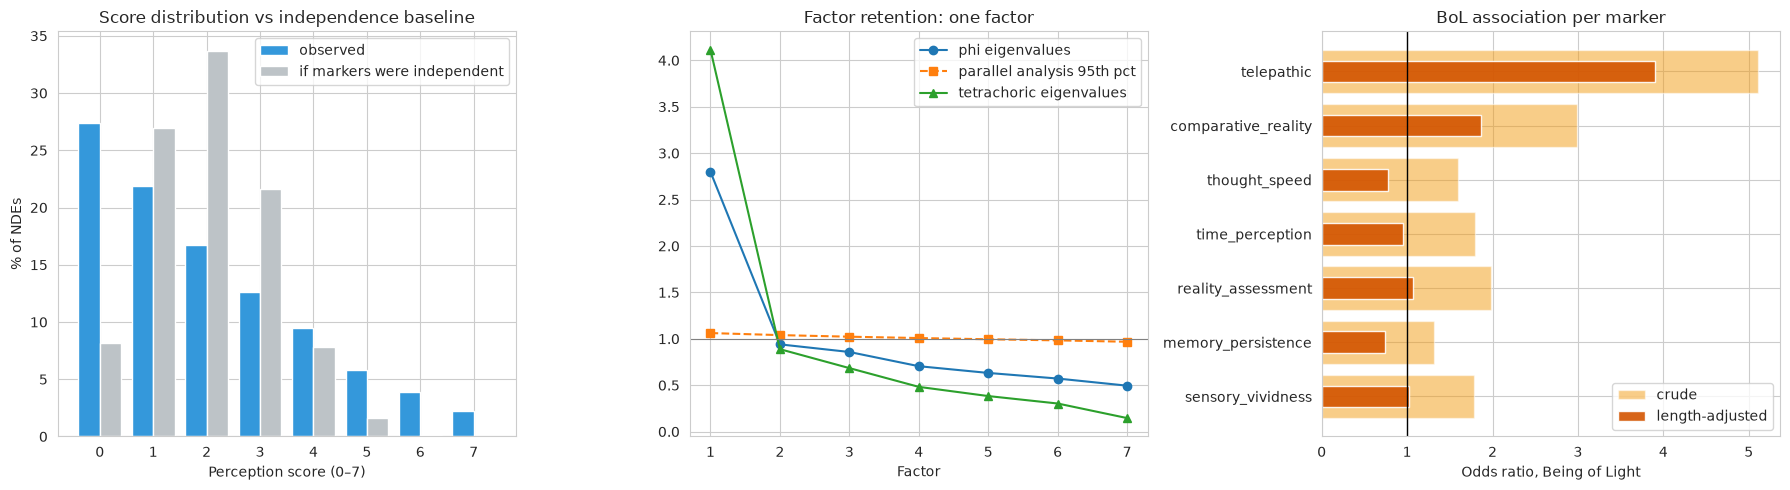

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ax = axes[0]
x = np.arange(8); w = 0.4
ax.bar(x - w/2, 100*obs.values, w, label="observed", color="#3498db")
ax.bar(x + w/2, 100*dist, w, label="if markers were independent", color="#bdc3c7")
ax.set_xlabel("Perception score (0–7)"); ax.set_ylabel("% of NDEs"); ax.legend(); ax.set_title("Score distribution vs independence baseline")
ax = axes[1]
ax.plot(range(1, 8), ev_phi, "o-", label="phi eigenvalues")
ax.plot(range(1, 8), pa95, "s--", label="parallel analysis 95th pct")
ax.plot(range(1, 8), ev_tet, "^-", label="tetrachoric eigenvalues")
ax.axhline(1, color="grey", lw=0.8); ax.set_xlabel("Factor"); ax.legend(); ax.set_title("Factor retention: one factor")
ax = axes[2]
ax.barh(bol_tab["marker"], bol_tab["crude OR"], color="#f39c12", alpha=0.5, label="crude")
ax.barh(bol_tab["marker"], bol_tab["length-adj OR"], color="#d35400", alpha=0.9, height=0.4, label="length-adjusted")
ax.axvline(1, color="black", lw=1); ax.set_xlabel("Odds ratio, Being of Light"); ax.legend(); ax.set_title("BoL association per marker")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "06_perception_degrees_summary.png", dpi=150, bbox_inches="tight"); plt.show()

---
## Part VII: Summary and interpretation (corrected)

| Hypothesis | Result | Assessment |
|---|---|---|
| H1 Prevalence hierarchy natural > spiritual > celestial | Most and least prevalent markers both "spiritual"; ρ ≈ −0.47 (predicted sign), p ≈ 0.28 | **Not supported** (direction right, ordering not) |
| H2 Coherent construct | 21/21 positive significant correlations; KR-20 ≈ 0.74; KMO ≈ 0.82. Length-controlled: six markers still cohere (15/15); telepathy does not | **Supported** for six markers; telepathy's membership is a length artefact |
| H3 Internal structure of 2+ factors | Raw: Kaiser, parallel analysis and tetrachoric eigenvalues all give 1 factor. Length-controlled: weak extra dimensions, not degree-aligned | **Not supported** |
| H6 Gradient rather than binary activation | Right-skewed with excess 0s and 5–7s; ~41% of variance explained by narrative length | Observed, **not diagnostic** |
| H4 Being of Light ↔ deeper perception | d ≈ 0.59 crude; +0.39 markers after length adjustment; only comparative reality and telepathy remain elevated | **Partially supported** |
| H5 Constant across religious backgrounds | Christian vs atheist/agnostic equivalent within ±0.5 (TOST p ≈ 0.005); η² ≈ 0.001 | **Supported** (Christian vs non-religious); underpowered for other traditions |

**Interpretation.** NDE accounts carry one dominant, internally consistent dimension of "enhanced perception" (six markers; it survives control for narrative length) that does not differ between Christian and non-religious experiencers — a result consistent with a universal perceptual state rather than religious priming. The finer predictions that would distinguish *discrete degrees* from a single intensity dimension (prevalence ordering, multi-factor structure) are not borne out. The Being-of-Light association survives, attenuated, for the two "celestial" markers.

**Speculative (not tested here):** the earlier version connected these findings to Palaeolithic geometric signs as a "correspondential vocabulary". Nothing in this dataset bears on that hypothesis; it is retained only as a speculative direction.

**Limitations.** (1) LLM-coded markers; inter-coder reliability measured in `08_extraction_reliability.ipynb` for telepathy (κ = 0.88) and comparative reality (κ = 0.74, test–retest 0.58); the other markers are untested. (2) "Not mentioned" is coded as absent, so scores mix experience with reporting completeness. (3) Self-selected archives. (4) Religion known for ~24% of records.